# Trend Detection with DBSCAN
DBSCAN clustering on TF-IDF text embeddings to find trending sub-topics within the `trending_topics` dataset.

## 1. Imports & Config

In [3]:
import os
os.makedirs("Results/DBSCAN", exist_ok=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import DBSCAN
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize
from sklearn.metrics import silhouette_score

from database_util import connect_database

sns.set_theme(style="whitegrid", palette="tab10")
plt.rcParams["figure.dpi"] = 100

RANDOM_STATE = 42

## 2. Load Data from PostgreSQL

In [4]:
conn = connect_database()

cursor = conn.cursor()
cursor.execute("""
    SELECT post_id, text_translated, niche, timestamp_utc, score, num_comments
    FROM final_trendingtopics
    WHERE text_translated IS NOT NULL
      AND TRIM(text_translated) != ''
""")
rows = cursor.fetchall()
cols = [desc[0] for desc in cursor.description]
df = pd.DataFrame(rows, columns=cols)
cursor.close()

df["timestamp_utc"] = pd.to_datetime(df["timestamp_utc"])
df["score"] = df["score"].fillna(0)
df["num_comments"] = df["num_comments"].fillna(0)
df["engagement"] = df["score"] + df["num_comments"]

print(f"Loaded {len(df):,} rows")
print(df["niche"].value_counts())

Loaded 7,090 rows
niche
movies         1588
worldnews      1518
technology     1417
smartphones    1226
gaming          818
science         523
Name: count, dtype: int64


## 3. Text Vectorisation (TF-IDF → SVD)

In [5]:
tfidf = TfidfVectorizer(
    max_features=8000,
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.85,
    sublinear_tf=True,
    stop_words="english"
)
X_tfidf = tfidf.fit_transform(df["text_translated"])
print(f"TF-IDF shape: {X_tfidf.shape}")

N_COMPONENTS = 100
svd = TruncatedSVD(n_components=N_COMPONENTS, random_state=RANDOM_STATE)
X_svd = svd.fit_transform(X_tfidf)
X_norm = normalize(X_svd)
print(f"SVD explained variance: {svd.explained_variance_ratio_.sum():.2%}")

TF-IDF shape: (7090, 8000)
SVD explained variance: 15.04%


## 4. Epsilon Tuning (k-distance plot)

C:\Users\rajib\AppData\Local\Temp\ipykernel_1340\1001413344.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


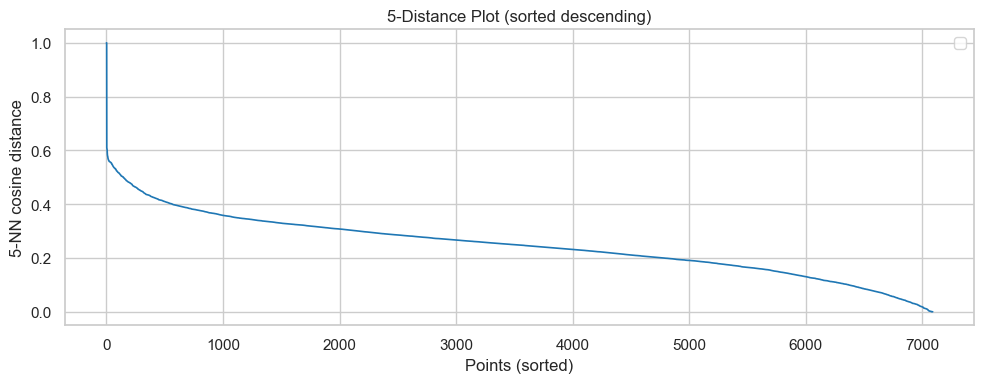

In [26]:
from sklearn.neighbors import NearestNeighbors

K = 5
nbrs = NearestNeighbors(n_neighbors=K, metric="cosine").fit(X_norm)
distances, _ = nbrs.kneighbors(X_norm)
k_distances = np.sort(distances[:, -1])[::-1]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(k_distances, linewidth=1.2)
ax.set_title(f"{K}-Distance Plot (sorted descending)")
ax.set_xlabel("Points (sorted)")
ax.set_ylabel(f"{K}-NN cosine distance")
ax.legend()
plt.tight_layout()
plt.savefig("Results/DBSCAN/dbscan_k_distance.png", bbox_inches="tight")
plt.show()

## 5. DBSCAN Clustering
Adjust  EPS (from distance plot), MIN_PTS for clustering

In [39]:
EPS     = 0.25
MIN_PTS = 5

dbscan = DBSCAN(eps=EPS, min_samples=MIN_PTS, metric="cosine", n_jobs=-1)
labels = dbscan.fit_predict(X_norm)

df["cluster"] = labels

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise    = (labels == -1).sum()
noise_pct  = n_noise / len(labels) * 100

print(f"Clusters found : {n_clusters}")
print(f"Noise points   : {n_noise:,} ({noise_pct:.1f}%)")
print(f"Clustered posts: {len(df) - n_noise:,}")

if n_clusters > 1:
    mask = labels != -1
    score = silhouette_score(X_norm[mask], labels[mask], metric="cosine", sample_size=3000)
    print(f"Silhouette score (excl. noise): {score:.4f}")

Clusters found : 53
Noise points   : 2,303 (32.5%)
Clustered posts: 4,787
Silhouette score (excl. noise): -0.0862


## 6. Cluster Sizes

C:\Users\rajib\AppData\Local\Temp\ipykernel_1340\3839870392.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cluster_counts.head(top_n), x="cluster", y="count",


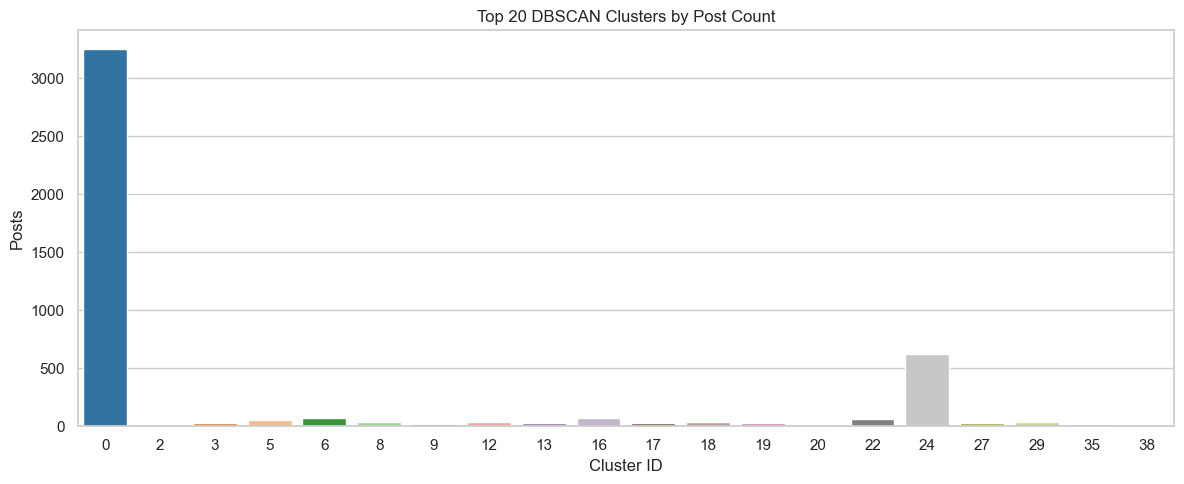

In [40]:
cluster_counts = (
    df[df["cluster"] != -1]
    .groupby("cluster")
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

top_n = min(20, len(cluster_counts))
fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=cluster_counts.head(top_n), x="cluster", y="count",
            palette="tab20", ax=ax)
ax.set_title(f"Top {top_n} DBSCAN Clusters by Post Count")
ax.set_xlabel("Cluster ID")
ax.set_ylabel("Posts")
plt.tight_layout()
plt.savefig("Results/DBSCAN/dbscan_cluster_sizes.png", bbox_inches="tight")
plt.show()

## 7. Cluster Keywords (Top TF-IDF Terms)

In [41]:
feature_names = tfidf.get_feature_names_out()
TOP_K_WORDS = 8

print(f"{'Cluster':>8}  {'Posts':>6}  Top Keywords")
print("=" * 80)

cluster_keywords = {}
for cid in cluster_counts["cluster"]:
    mask = (df["cluster"] == cid).values
    centroid = X_tfidf[mask].mean(axis=0)
    centroid = np.asarray(centroid).flatten()
    top_idx  = centroid.argsort()[::-1][:TOP_K_WORDS]
    keywords = ", ".join(feature_names[top_idx])
    cluster_keywords[cid] = keywords
    n = mask.sum()
    print(f"{cid:>8}  {n:>6}  {keywords}")

df["cluster_keywords"] = df["cluster"].map(cluster_keywords)

 Cluster   Posts  Top Keywords
       0    3250  iran, ai, movie, game, says, like, new, trump
      24     625  phone, pro, iphone, camera, good, battery, samsung, ultra
      16      74  social, social media, media, ban, media ban, people, addiction, media addiction
       6      71  data, centers, data centers, data center, center, ai, ai data, china
      22      62  microsoft, windows, windows 11, 11, copilot, xbox, game pass, xbox game
       5      52  million, 000, 10 000, 10, ai, settlement, tesla, repair
      12      39  military, iran, says, military says, airspace, eastern, pacific, prepares
      18      36  apple, cook, tim cook, tim, fbi, deleted, ternus, ceo
      29      36  korea, south, north, north korea, south korea, south africa, africa, korean
       8      35  warner, warner bros, bros, paramount, merger, discovery, paramount warner, hollywood
      27      30  japan, tsunami, export, arms, warning, exports, industries, nato
      17      29  fuel, prices, ener

## 8. Topic Distribution per Cluster

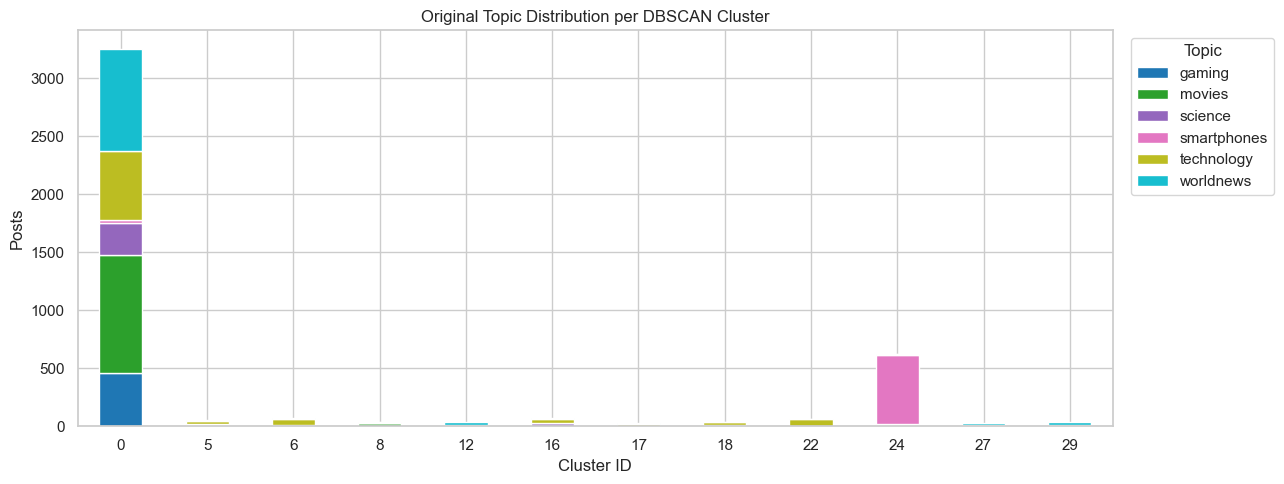

In [42]:
top_clusters = cluster_counts.head(12)["cluster"].tolist()
pivot = (
    df[df["cluster"].isin(top_clusters)]
    .groupby(["cluster", "niche"])
    .size()
    .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(13, 5))
pivot.plot(kind="bar", stacked=True, colormap="tab10", ax=ax)
ax.set_title("Original Topic Distribution per DBSCAN Cluster")
ax.set_xlabel("Cluster ID")
ax.set_ylabel("Posts")
ax.legend(title="Topic", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("Results/DBSCAN/dbscan_topic_distribution.png", bbox_inches="tight")
plt.show()

## 9. Engagement Analytics per Cluster

         Avg Engagement  Median      Total
cluster                                   
0                1947.6   188.5  6329623.0
6                4483.8   681.0   318352.0
5                3558.8  1051.0   185056.0
16               1990.1   551.0   147270.0
12               3210.9   486.0   125227.0
22               1672.2   476.0   103678.0
17               3473.2   281.0   100722.0
8                2519.4   454.0    88179.0
27               1394.7   154.0    41842.0
24                 61.3     8.0    38309.0
18                751.3    34.0    27048.0
29                699.3    97.0    25175.0


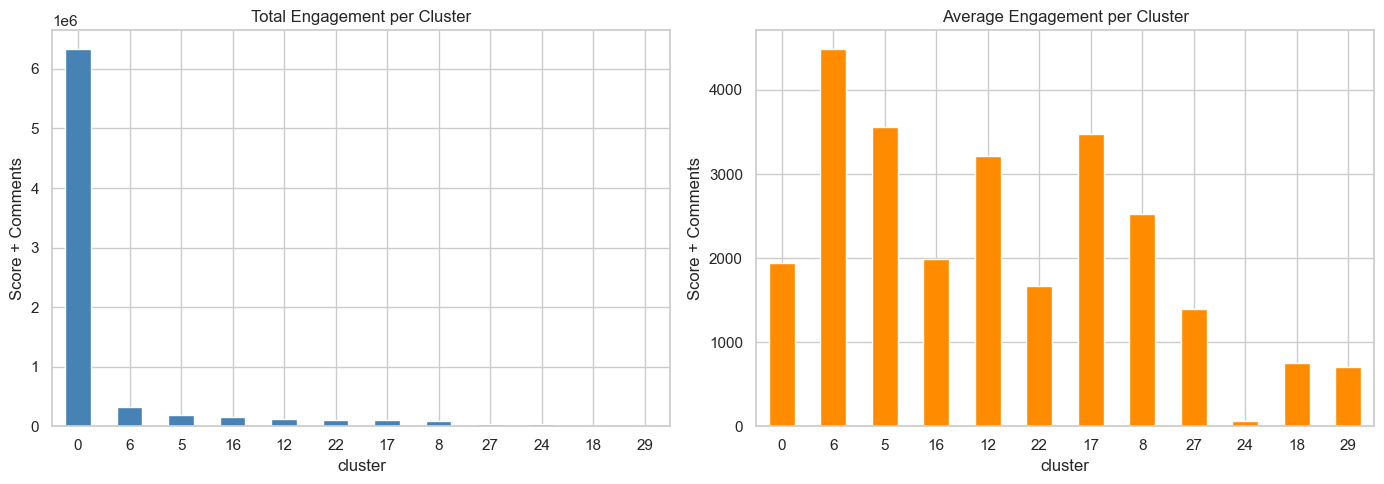

In [43]:
eng_stats = (
    df[df["cluster"].isin(top_clusters)]
    .groupby("cluster")["engagement"]
    .agg(["mean", "median", "sum"])
    .rename(columns={"mean": "Avg Engagement", "median": "Median", "sum": "Total"})
    .sort_values("Total", ascending=False)
)

print(eng_stats.round(1).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

eng_stats["Total"].plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Total Engagement per Cluster")
axes[0].set_ylabel("Score + Comments")
axes[0].tick_params(axis="x", rotation=0)

eng_stats["Avg Engagement"].plot(kind="bar", ax=axes[1], color="darkorange")
axes[1].set_title("Average Engagement per Cluster")
axes[1].set_ylabel("Score + Comments")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig("Results/DBSCAN/dbscan_engagement.png", bbox_inches="tight")
plt.show()

## 10. Cluster Activity Over Time

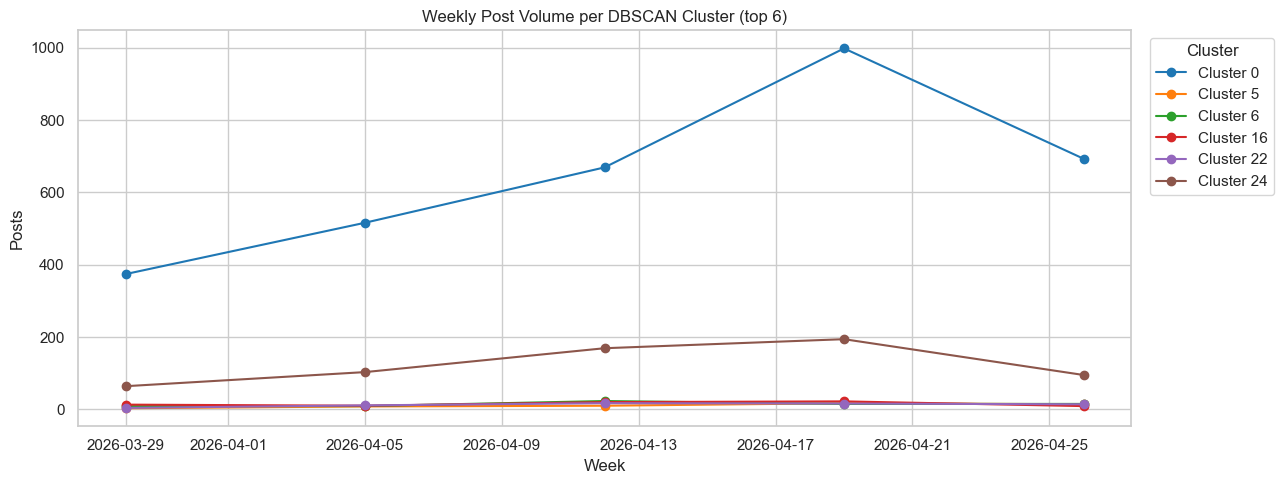

In [44]:
time_df = (
    df[df["cluster"].isin(top_clusters[:6])]
    .groupby([pd.Grouper(key="timestamp_utc", freq="W"), "cluster"])
    .size()
    .reset_index(name="count")
)

fig, ax = plt.subplots(figsize=(13, 5))
for cid, grp in time_df.groupby("cluster"):
    ax.plot(grp["timestamp_utc"], grp["count"], marker="o", label=f"Cluster {cid}")

ax.set_title("Weekly Post Volume per DBSCAN Cluster (top 6)")
ax.set_xlabel("Week")
ax.set_ylabel("Posts")
ax.legend(title="Cluster", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.savefig("Results/DBSCAN/dbscan_time_series.png", bbox_inches="tight")
plt.show()

## 11. 2D Visualisation (SVD → 2 components)

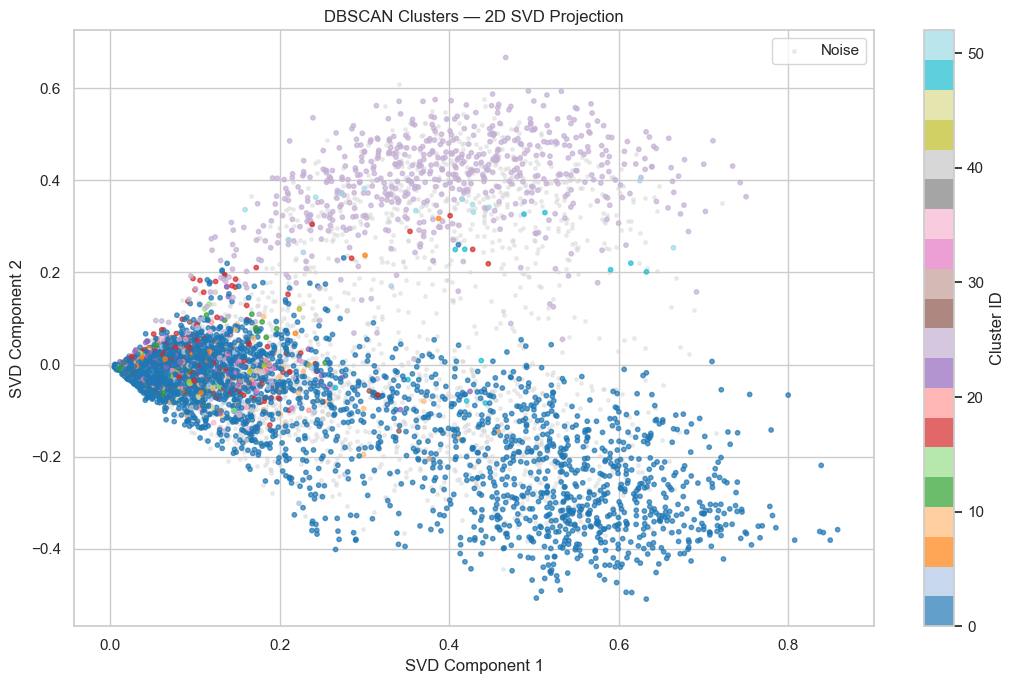

In [45]:
svd2 = TruncatedSVD(n_components=2, random_state=RANDOM_STATE)
X_2d = svd2.fit_transform(X_norm)

plot_df = pd.DataFrame({"x": X_2d[:, 0], "y": X_2d[:, 1], "cluster": labels})

noise_mask   = plot_df["cluster"] == -1
cluster_mask = ~noise_mask

fig, ax = plt.subplots(figsize=(11, 7))
ax.scatter(plot_df.loc[noise_mask, "x"], plot_df.loc[noise_mask, "y"],
           c="lightgrey", s=6, alpha=0.4, label="Noise")

scatter = ax.scatter(
    plot_df.loc[cluster_mask, "x"],
    plot_df.loc[cluster_mask, "y"],
    c=plot_df.loc[cluster_mask, "cluster"],
    cmap="tab20", s=10, alpha=0.7
)
plt.colorbar(scatter, ax=ax, label="Cluster ID")
ax.set_title("DBSCAN Clusters — 2D SVD Projection")
ax.set_xlabel("SVD Component 1")
ax.set_ylabel("SVD Component 2")
ax.legend()
plt.tight_layout()
plt.savefig("Results/DBSCAN/dbscan_2d.png", bbox_inches="tight")
plt.show()

## 12. Summary Table — Top Clusters

In [46]:
summary = (
    df[df["cluster"] != -1]
    .groupby("cluster")
    .agg(
        posts=("post_id", "count"),
        avg_engagement=("engagement", "mean"),
        total_engagement=("engagement", "sum"),
        dominant_topic=("niche", lambda x: x.value_counts().index[0]),
        keywords=("cluster_keywords", "first")
    )
    .sort_values("posts", ascending=False)
    .head(15)
)

summary["avg_engagement"] = summary["avg_engagement"].round(1)
summary["total_engagement"] = summary["total_engagement"].astype(int)

print("\n── DBSCAN Cluster Summary ──")
print(summary.to_string())


── DBSCAN Cluster Summary ──
         posts  avg_engagement  total_engagement dominant_topic                                                                              keywords
cluster                                                                                                                                              
0         3250          1947.6           6329623         movies                                         iran, ai, movie, game, says, like, new, trump
24         625            61.3             38309    smartphones                             phone, pro, iphone, camera, good, battery, samsung, ultra
16          74          1990.1            147270     technology       social, social media, media, ban, media ban, people, addiction, media addiction
6           71          4483.8            318352     technology                  data, centers, data centers, data center, center, ai, ai data, china
22          62          1672.2            103678     technology       

## 13. Trend Report

In [47]:
report = (
    df[df["cluster"] != -1]
    .groupby("cluster")
    .agg(
        posts=("post_id", "count"),
        avg_engagement=("engagement", "mean"),
        total_engagement=("engagement", "sum"),
        dominant_topic=("niche", lambda x: x.value_counts().index[0]),
        first_seen=("timestamp_utc", "min"),
        last_seen=("timestamp_utc", "max"),
        keywords=("cluster_keywords", "first")
    )
    .sort_values("total_engagement", ascending=False)
    .reset_index()
)

report["avg_engagement"] = report["avg_engagement"].round(1)
report["total_engagement"] = report["total_engagement"].astype(int)

print("=" * 80)
print("EMERGING TRENDS REPORT")
print("=" * 80)
for _, row in report.iterrows():
    print(f"\n#{int(row['cluster'])} | {row['dominant_topic']}")
    print(f"   Keywords   : {row['keywords']}")
    print(f"   Posts      : {row['posts']}  |  Total Engagement: {row['total_engagement']}  |  Avg: {row['avg_engagement']}")
    print(f"   Active     : {row['first_seen'].date()} → {row['last_seen'].date()}")
print("\n" + "=" * 80)

report.to_csv("Results/DBSCAN/trend_report_dbscan.csv", index=False)

EMERGING TRENDS REPORT

#0 | movies
   Keywords   : iran, ai, movie, game, says, like, new, trump
   Posts      : 3250  |  Total Engagement: 6329623  |  Avg: 1947.6
   Active     : 2026-03-25 → 2026-04-24

#6 | technology
   Keywords   : data, centers, data centers, data center, center, ai, ai data, china
   Posts      : 71  |  Total Engagement: 318352  |  Avg: 4483.8
   Active     : 2026-03-25 → 2026-04-24

#2 | technology
   Keywords   : sam altman, altman, sam, openai, home, attack, ceo, ai
   Posts      : 21  |  Total Engagement: 211323  |  Avg: 10063.0
   Active     : 2026-03-25 → 2026-04-23

#5 | technology
   Keywords   : million, 000, 10 000, 10, ai, settlement, tesla, repair
   Posts      : 52  |  Total Engagement: 185056  |  Avg: 3558.8
   Active     : 2026-03-25 → 2026-04-24

#16 | technology
   Keywords   : social, social media, media, ban, media ban, people, addiction, media addiction
   Posts      : 74  |  Total Engagement: 147270  |  Avg: 1990.1
   Active     : 2026-03-2